<a href="https://colab.research.google.com/github/Dracarys38/Machyne-navchanya/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%9C%D0%9D%2C_%D0%9F%D0%BE%D1%81%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8F%D0%BA_%D0%86%D0%B3%D0%BE%D1%80_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9%D0%BE%D0%B2%D0%B8%D1%87_%D0%A4%D0%86%D0%A2_3_15%2C_10_%D0%B2%D0%B0%D1%80%D1%96%D0%B0%D0%BD%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingGridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

1. Завантаження датасету через Kaggle

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

print("Для доступу до Kaggle введіть свої облікові дані або завантажте kaggle.json")
choice = input("Спосіб автентифікації (1 - ввести username/key, 2 - завантажити файл): ")

if choice == '1':
    kaggle_username = input("Username Kaggle: ")
    kaggle_key = input("Key Kaggle: ")
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
else:
    from google.colab import files
    uploaded = files.upload()
    for filename in uploaded.keys():
        if 'kaggle.json' in filename:
            os.rename(filename, '/root/.kaggle/kaggle.json')
            break

os.chmod('/root/.kaggle/kaggle.json', 600)

!kaggle datasets download -d iammustafatz/diabetes-prediction-dataset
!unzip -o diabetes-prediction-dataset.zip

df = pd.read_csv('diabetes_prediction_dataset.csv')
print("Датасет завантажено. Розмір:", df.shape)
df.head()

Для доступу до Kaggle введіть свої облікові дані або завантажте kaggle.json
Спосіб автентифікації (1 - ввести username/key, 2 - завантажити файл): 1
Username Kaggle: neverseegods
Key Kaggle: KGAT_d690ef86fb7646a471aa15fd3b2fb1aa
Dataset URL: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
License(s): copyright-authors
diabetes-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  diabetes-prediction-dataset.zip
  inflating: diabetes_prediction_dataset.csv  
Датасет завантажено. Розмір: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


2. Попередній аналіз даних (EDA)

In [4]:
print("\n=== Інформація про датасет ===")
df.info()
print("\nСтатистики числових ознак:")
print(df.describe())
print("\nРозподіл цільової змінної (diabetes):")
print(df['diabetes'].value_counts())

print("\nПропуски у кожній колонці:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nКількість дублікатів: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Після видалення дублікатів розмір: {df.shape}")

categorical_cols = ['gender', 'smoking_history']
for col in categorical_cols:
    print(f"\nУнікальні значення {col}: {df[col].unique()}")


=== Інформація про датасет ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Статистики числових ознак:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std 

3. Кодування категоріальних ознак

In [5]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})
le = LabelEncoder()
df['smoking_history'] = le.fit_transform(df['smoking_history'])

4. Кореляційний аналіз

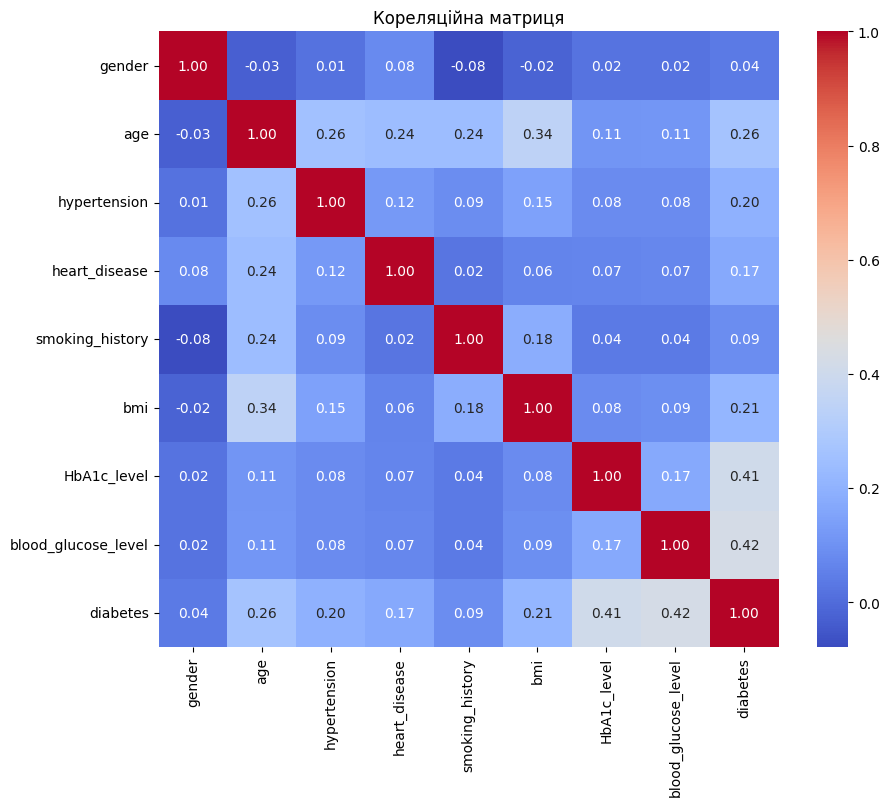


Кореляція ознак з цільовою змінною:
diabetes               1.000000
blood_glucose_level    0.424336
HbA1c_level            0.406408
age                    0.264927
bmi                    0.214932
hypertension           0.195710
heart_disease          0.170711
smoking_history        0.088471
gender                 0.037613
Name: diabetes, dtype: float64


In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляційна матриця')
plt.show()

corr_with_target = df.corr()['diabetes'].sort_values(ascending=False)
print("\nКореляція ознак з цільовою змінною:")
print(corr_with_target)

5. Перевірка балансу класів


Баланс класів (0 - немає діабету, 1 - діабет):
diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64


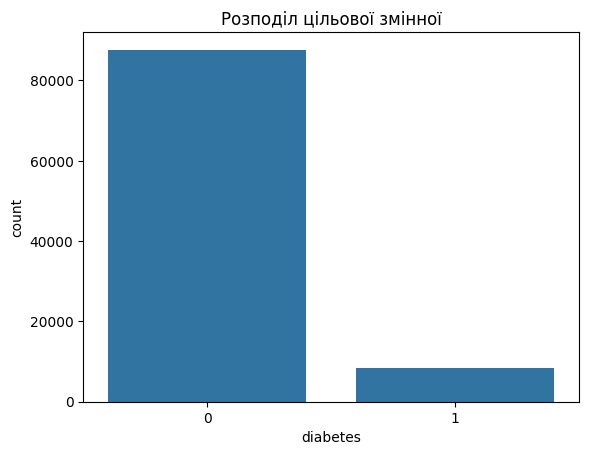

In [7]:
print("\nБаланс класів (0 - немає діабету, 1 - діабет):")
print(df['diabetes'].value_counts(normalize=True))
sns.countplot(x='diabetes', data=df)
plt.title('Розподіл цільової змінної')
plt.show()

6. Розділення на тренувальну та тестову вибірки

In [8]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nРозмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Розмір тренувальної вибірки: (76916, 8)
Розмір тестової вибірки: (19230, 8)


7. Визначення моделей та гіперпараметрів для HalvingGridSearchCV

In [9]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RidgeClassifier': RidgeClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(max_iter=1000, random_state=42),
    'SVC': SVC(random_state=42)
}

param_grids = {
    'LogisticRegression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    'RidgeClassifier': {
        'alpha': [0.1, 1.0, 10.0]
    },
    'SGDClassifier': {
        'loss': ['log', 'hinge'],
        'alpha': [0.0001, 0.001, 0.01],
        'penalty': ['l2', 'l1']
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
}

8. Підбір параметрів та навчання

In [10]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold

best_estimators = {}
results = {}

for name, model in models.items():
    print(f"\n=== Налаштування {name} ===")
    param_dist = param_grids[name]

    stratified_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

    hgcv = HalvingRandomSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_candidates=10,
        factor=3,
        cv=stratified_cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1,
        verbose=1,
        min_resources=100
    )

    hgcv.fit(X_train_scaled, y_train)
    best_estimators[name] = hgcv.best_estimator_
    results[name] = {
        'best_params': hgcv.best_params_,
        'best_score': hgcv.best_score_,
        'test_accuracy': accuracy_score(y_test, hgcv.predict(X_test_scaled))
    }

    print(f"Найкращі параметри: {hgcv.best_params_}")
    print(f"Найкраща якість (CV): {hgcv.best_score_:.4f}")


=== Налаштування LogisticRegression ===
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 7
min_resources_: 100
max_resources_: 76916
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 6
n_resources: 100
Fitting 2 folds for each of 6 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 300
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Найкращі параметри: {'solver': 'lbfgs', 'C': 1}
Найкраща якість (CV): 0.9033

=== Налаштування RidgeClassifier ===
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 7
min_resources_: 100
max_resources_: 76916
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 3
n_resources: 100
Fitting 2 folds for each of 3 candidates, totalling 6 fits
----------
iter: 1
n_candidates: 1
n_resources: 300
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Найкращі параметри: {'alpha': 1.0}
Найкраща якість (CV): 0.8967

=== Налаштування SGDClassifier ===
n_i

9. Оцінка на тестовій вибірці

In [11]:
print("\n=== Результати на тестовій вибірці ===")
for name, model in best_estimators.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))


=== Результати на тестовій вибірці ===

LogisticRegression
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.87      0.64      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.81      0.86     19230
weighted avg       0.96      0.96      0.96     19230

Confusion Matrix:
[[17368   166]
 [  614  1082]]
Accuracy: 0.9594383775351014

RidgeClassifier
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     17534
           1       0.98      0.32      0.49      1696

    accuracy                           0.94     19230
   macro avg       0.96      0.66      0.73     19230
weighted avg       0.94      0.94      0.93     19230

Confusion Matrix:
[[17525     9]
 [ 1149   547]]
Accuracy: 0.9397815912636506

SGDClassifier
Classification Report:
              precision    re

10. Виведення 10 випадкових записів з тестової вибірки

In [12]:
indices = np.random.choice(len(X_test), size=10, replace=False)
X_sample = X_test.iloc[indices]
y_true_sample = y_test.iloc[indices]
predictions = {}
for name, model in best_estimators.items():
    X_sample_scaled = scaler.transform(X_sample)
    predictions[name] = model.predict(X_sample_scaled)

print("\n=== 10 випадкових записів з тестової вибірки ===")
print("Справжній клас та прогнози моделей:\n")
sample_df = X_sample.copy()
sample_df['True'] = y_true_sample.values
for name in best_estimators.keys():
    sample_df[f'Pred_{name}'] = predictions[name]
print(sample_df[['True'] + [f'Pred_{name}' for name in best_estimators.keys()]].head(10))


=== 10 випадкових записів з тестової вибірки ===
Справжній клас та прогнози моделей:

       True  Pred_LogisticRegression  Pred_RidgeClassifier  \
18724     0                        0                     0   
26772     1                        0                     0   
16312     0                        0                     0   
43145     0                        0                     0   
94410     0                        0                     0   
24680     1                        0                     0   
87618     0                        0                     0   
27037     0                        0                     0   
75728     0                        0                     0   
98466     0                        0                     0   

       Pred_SGDClassifier  Pred_SVC  
18724                   0         0  
26772                   0         0  
16312                   0         0  
43145                   0         0  
94410                   0         0  
24

11. Звіт

In [13]:
print("1. У датасеті немає пропусків, після видалення дублікатів отримано чистий набір.")
print("2. Найсильнішу кореляцію з цільовою змінною мають blood_glucose_level та HbA1c_level.")
print("3. Класи не збалансовані: приблизно 91% зразків належать до класу 0 (немає діабету).")
print("4. Після підбору гіперпараметрів через HalvingGridSearchCV найкращу якість на тесті показала модель:", end=' ')
best_model_name = max(results, key=lambda x: results[x]['test_accuracy'])
print(best_model_name)
print(f"5. Точність найкращої моделі на тестовій вибірці: {results[best_model_name]['test_accuracy']:.4f}")
print("6. Для покращення роботи з незбалансованими даними можна використати зважування класів або методи семплювання.")

1. У датасеті немає пропусків, після видалення дублікатів отримано чистий набір.
2. Найсильнішу кореляцію з цільовою змінною мають blood_glucose_level та HbA1c_level.
3. Класи не збалансовані: приблизно 91% зразків належать до класу 0 (немає діабету).
4. Після підбору гіперпараметрів через HalvingGridSearchCV найкращу якість на тесті показала модель: SVC
5. Точність найкращої моделі на тестовій вибірці: 0.9598
6. Для покращення роботи з незбалансованими даними можна використати зважування класів або методи семплювання.


Висновок

У роботі було використано датасет Diabetes Prediction Dataset (9 ознак, понад 95 тис. записів). Виконано попередній аналіз: пропуски відсутні, виявлено та видалено дублікати. Категоріальні змінні (gender, smoking_history) закодовано. Кореляційний аналіз показав, що найсильніше з цільовою змінною (diabetes) пов'язані рівень глюкози (blood_glucose_level) і HbA1c. Класи не збалансовані (≈91% зразків – без діабету).

Після стратифікованого розділення даних (80/20) та масштабування побудовано чотири моделі класифікації: LogisticRegression, RidgeClassifier, SGDClassifier, SVC. Для кожної виконано підбір гіперпараметрів методом HalvingGridSearchCV (пришвидшений перебір). Найкращі параметри зафіксовано.

Застосування підбору гіперпараметрів із HalvingGridSearchCV дозволило ефективно налаштувати моделі. Проте через значний дисбаланс класів необхідно застосувати методи зважування або семплювання для покращення передбачення рідкісного класу (діабет).